# Bandit benchmark notebook

Этот ноутбук запускает benchmark-пайплайн (аналогично `src/run_benchmark.py`) на вашем датасете.

## 1) Настройки

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from run_benchmark import load_dataset
from bandit_benchmark import (
    CatBoostPolicy,
    LogisticTSLibPolicy,
    PartitionedTSLibPolicy,
    RandomPolicy,
    EpsilonGreedyPolicy,
    UCBPolicy,
    ThompsonSamplingPolicy,
    build_expected_reward_estimator,
    core_scenarios,
    default_five_scenarios,
    make_simulated_environment,
    preprocess_bandit_dataframe,
    run_scenarios,
    split_train_test_by_date,
)
from prepare_datasets import stage1_make_splits, stage2_scale_features


In [2]:
# Укажите путь к данным (.tsv или .parquet)
DATA_PATH = ROOT / 'data' / 'events.tsv'
PREPARED_TRAIN_PATH = ROOT / 'artifacts' / 'datasets' / 'train_prepared.parquet'
PREPARED_TEST_PATH = ROOT / 'artifacts' / 'datasets' / 'test_prepared.parquet'
USE_PREPARED_SPLITS = True
TEST_RATIO = 0.5
EPSILON = 0.1
SEED = 42
SIMULATE = False
STOCHASTIC_SIM = True
FULL_SCENARIOS = True


## 2) Загрузка и препроцессинг

In [3]:
if USE_PREPARED_SPLITS and PREPARED_TRAIN_PATH.exists() and PREPARED_TEST_PATH.exists():
    train_df = pl.read_parquet(PREPARED_TRAIN_PATH)
    test_df = pl.read_parquet(PREPARED_TEST_PATH)
    print('loaded prepared splits')
else:
    # Stage 1: load -> split -> filter -> save
    train_s1, test_s1 = stage1_make_splits(str(DATA_PATH), str(ROOT / 'artifacts' / 'datasets'), TEST_RATIO, SEED)
    # Stage 2: scale features and save prepared datasets
    train_final, test_final = stage2_scale_features(train_s1, test_s1, str(ROOT / 'artifacts' / 'datasets'))
    train_df = pl.read_parquet(train_final)
    test_df = pl.read_parquet(test_final)

print('train:', train_df.height, 'test(random only):', test_df.height)


loaded prepared splits
train: 12701839 test(random only): 3925311


## 3) Конфиг политик и сценариев

In [4]:
policy_factories = {
    'random': lambda: RandomPolicy(seed=SEED),
    'epsilon_greedy': lambda: EpsilonGreedyPolicy(epsilon=EPSILON, seed=SEED),
    'ucb': lambda: UCBPolicy(),
    'thompson_sampling': lambda: ThompsonSamplingPolicy(seed=SEED),
}

try:
    import catboost  # noqa: F401
    policy_factories['catboost No update'] = lambda: CatBoostPolicy(random_seed=SEED,can_update_online=False)
except Exception:
    print('catboost is unavailable: skipping CatBoostPolicy')

scenarios = default_five_scenarios() if FULL_SCENARIOS else core_scenarios()

## 4) Запуск benchmark

In [5]:
env_reward = None
if SIMULATE:
    expected_fn = build_expected_reward_estimator(train_df)
    env_reward = make_simulated_environment(
        proba_predictor=expected_fn,
        stochastic=STOCHASTIC_SIM,
        seed=SEED,
    )

result = run_scenarios(
    train_df=train_df,
    test_df=test_df,
    policy_factories=policy_factories,
    scenarios=scenarios,
    env_reward=env_reward,
    show_progress=True,
)

metrics_df = result['metrics']
history_df = result['history']
action_stats_df = result['action_stats']

display(metrics_df)
print('history rows:', len(history_df))
if SIMULATE:
    display(action_stats_df)


case_1_random_pretrain_predict_only/r

case_1_random_pretrain_predict_only/random: train_unique_actions=50
case_1_random_pretrain_predict_only/random: step=163185, date=2026-02-02 00:00:00, unique_actions_total=50, unique_actions_new_in_day=0
case_1_random_pretrain_predict_only/random: step=453405, date=2026-02-03 00:00:00, unique_actions_total=51, unique_actions_new_in_day=1
case_1_random_pretrain_predict_only/random: step=666661, date=2026-02-04 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_1_random_pretrain_predict_only/random: step=874669, date=2026-02-05 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_1_random_pretrain_predict_only/random: step=1033701, date=2026-02-06 00:00:00, unique_actions_total=53, unique_actions_new_in_day=2
case_1_random_pretrain_predict_only/random: step=1183132, date=2026-02-07 00:00:00, unique_actions_total=53, unique_actions_new_in_day=0
case_1_random_pretrain_predict_only/random: step=1289862, date=2026-02-08 00:00:00, unique_actions_total=53, uniqu

case_1_random_pretrain_predict_only/e

case_1_random_pretrain_predict_only/epsilon_greedy: train_unique_actions=50
case_1_random_pretrain_predict_only/epsilon_greedy: step=163185, date=2026-02-02 00:00:00, unique_actions_total=50, unique_actions_new_in_day=0
case_1_random_pretrain_predict_only/epsilon_greedy: step=453405, date=2026-02-03 00:00:00, unique_actions_total=51, unique_actions_new_in_day=1
case_1_random_pretrain_predict_only/epsilon_greedy: step=666661, date=2026-02-04 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_1_random_pretrain_predict_only/epsilon_greedy: step=874669, date=2026-02-05 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_1_random_pretrain_predict_only/epsilon_greedy: step=1033701, date=2026-02-06 00:00:00, unique_actions_total=53, unique_actions_new_in_day=2
case_1_random_pretrain_predict_only/epsilon_greedy: step=1183132, date=2026-02-07 00:00:00, unique_actions_total=53, unique_actions_new_in_day=0
case_1_random_pretrain_predict_only/epsilon_greedy: step=1

case_1_random_pretrain_predict_only/u

...

case_5_no_pretrain_online_update/thompson_sampling: train_unique_actions=0
case_5_no_pretrain_online_update/thompson_sampling: step=163185, date=2026-02-02 00:00:00, unique_actions_total=28, unique_actions_new_in_day=28
case_5_no_pretrain_online_update/thompson_sampling: step=453405, date=2026-02-03 00:00:00, unique_actions_total=29, unique_actions_new_in_day=1
case_5_no_pretrain_online_update/thompson_sampling: step=666661, date=2026-02-04 00:00:00, unique_actions_total=29, unique_actions_new_in_day=0
case_5_no_pretrain_online_update/thompson_sampling: step=874669, date=2026-02-05 00:00:00, unique_actions_total=29, unique_actions_new_in_day=0
case_5_no_pretrain_online_update/thompson_sampling: step=1033701, date=2026-02-06 00:00:00, unique_actions_total=31, unique_actions_new_in_day=2
case_5_no_pretrain_online_update/thompson_sampling: step=1183132, date=2026-02-07 00:00:00, unique_actions_total=31, unique_actions_new_in_day=0
case_5_no_pretrain_online_update/thompson_sampling: step=1

case_5_no_pretrain_online_update/catboost No update

case_5_no_pretrain_online_update/catboost No update: train_unique_actions=0
case_5_no_pretrain_online_update/catboost No update: step=163185, date=2026-02-02 00:00:00, unique_actions_total=28, unique_actions_new_in_day=28
case_5_no_pretrain_online_update/catboost No update: step=453405, date=2026-02-03 00:00:00, unique_actions_total=29, unique_actions_new_in_day=1
case_5_no_pretrain_online_update/catboost No update: step=666661, date=2026-02-04 00:00:00, unique_actions_total=29, unique_actions_new_in_day=0
case_5_no_pretrain_online_update/catboost No update: step=874669, date=2026-02-05 00:00:00, unique_actions_total=29, unique_actions_new_in_day=0
case_5_no_pretrain_online_update/catboost No update: step=1033701, date=2026-02-06 00:00:00, unique_actions_total=31, unique_actions_new_in_day=2
case_5_no_pretrain_online_update/catboost No update: step=1183132, date=2026-02-07 00:00:00, unique_actions_total=31, unique_actions_new_in_day=0
case_5_no_pretrain_online_update/catboost No update

,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,train_unique_actions,scenario,algo
0,3925311,2764431,47129.0,0.017048,67938.0,0.017308,0.704258,10208.645841,0.003693,50052.722959,0.012751,50,case_1_random_pretrain_predict_only,random
1,3925311,2766613,52556.0,0.018997,82892.0,0.021117,0.704814,5249.127997,0.001897,44625.722959,0.011369,50,case_1_random_pretrain_predict_only,epsilon_greedy
2,3925311,2757945,51855.0,0.018802,78465.0,0.019989,0.702605,5634.481317,0.002043,45326.722959,0.011547,50,case_1_random_pretrain_predict_only,ucb
3,3925311,2760946,51882.0,0.018791,78559.0,0.020013,0.703370,5682.246703,0.002058,45299.722959,0.011540,50,case_1_random_pretrain_predict_only,thompson_sampling
4,3925311,2761880,55433.0,0.020071,89977.0,0.022922,0.703608,2378.798701,0.000861,41748.722959,0.010636,50,case_1_random_pretrain_predict_only,catboost No update
5,3925311,2764431,47129.0,0.017048,67938.0,0.017308,0.704258,10208.645841,0.003693,50052.722959,0.012751,50,case_2_random_pretrain_online_update,random
6,3925311,2761985,56418.0,0.020427,93585.0,0.023841,0.703635,1436.451915,0.000520,40763.722959,0.010385,50,case_2_random_pretrain_online_update,epsilon_greedy
7,3925311,2774748,57266.0,0.020638,95224.0,0.024259,0.706886,746.912702,0.000269,39915.722959,0.010169,50,case_2_random_pretrain_online_update,ucb
8,3925311,2766436,57761.0,0.020879,97026.0,0.024718,0.704769,204.326288,0.000074,39420.722959,0.010043,50,case_2_random_pretrain_online_update,thompson_sampling
9,3925311,2761880,55433.0,0.020071,89977.0,0.022922,0.703608,2378.798701,0.000861,41748.722959,0.010636,50,case_2_random_pretrain_online_update,catboost No update


history rows: 69104981


In [11]:
metrics_df.sort_values(by=["ips_ctr"], ascending=False)

,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,train_unique_actions,scenario,algo
8,3925311,2766436,57761.0,0.020879,97026.0,0.024718,0.704769,204.326288,0.000074,39420.722959,0.010043,50,case_2_random_pretrain_online_update,thompson_sampling
18,3925311,2765540,57728.0,0.020874,96934.0,0.024695,0.704540,223.865801,0.000081,39453.722959,0.010051,53,case_4_all_pretrain_online_update,thompson_sampling
23,3925311,2764515,57285.0,0.020722,95791.0,0.024403,0.704279,561.352496,0.000203,39896.722959,0.010164,0,case_5_no_pretrain_online_update,thompson_sampling
7,3925311,2774748,57266.0,0.020638,95224.0,0.024259,0.706886,746.912702,0.000269,39915.722959,0.010169,50,case_2_random_pretrain_online_update,ucb
17,3925311,2775068,57267.0,0.020636,95060.0,0.024217,0.706968,764.683367,0.000276,39914.722959,0.010169,53,case_4_all_pretrain_online_update,ucb
6,3925311,2761985,56418.0,0.020427,93585.0,0.023841,0.703635,1436.451915,0.000520,40763.722959,0.010385,50,case_2_random_pretrain_online_update,epsilon_greedy
22,3925311,2772104,56462.0,0.020368,93480.0,0.023815,0.706213,1314.538284,0.000474,40719.722959,0.010374,0,case_5_no_pretrain_online_update,ucb
16,3925311,2761893,56387.0,0.020416,93480.0,0.023815,0.703611,1462.321097,0.000529,40794.722959,0.010393,53,case_4_all_pretrain_online_update,epsilon_greedy
21,3925311,2761084,56073.0,0.020308,92673.0,0.023609,0.703405,1683.791401,0.000610,41108.722959,0.010473,0,case_5_no_pretrain_online_update,epsilon_greedy
9,3925311,2761880,55433.0,0.020071,89977.0,0.022922,0.703608,2378.798701,0.000861,41748.722959,0.010636,50,case_2_random_pretrain_online_update,catboost No update


## 5) Графики по сценариям

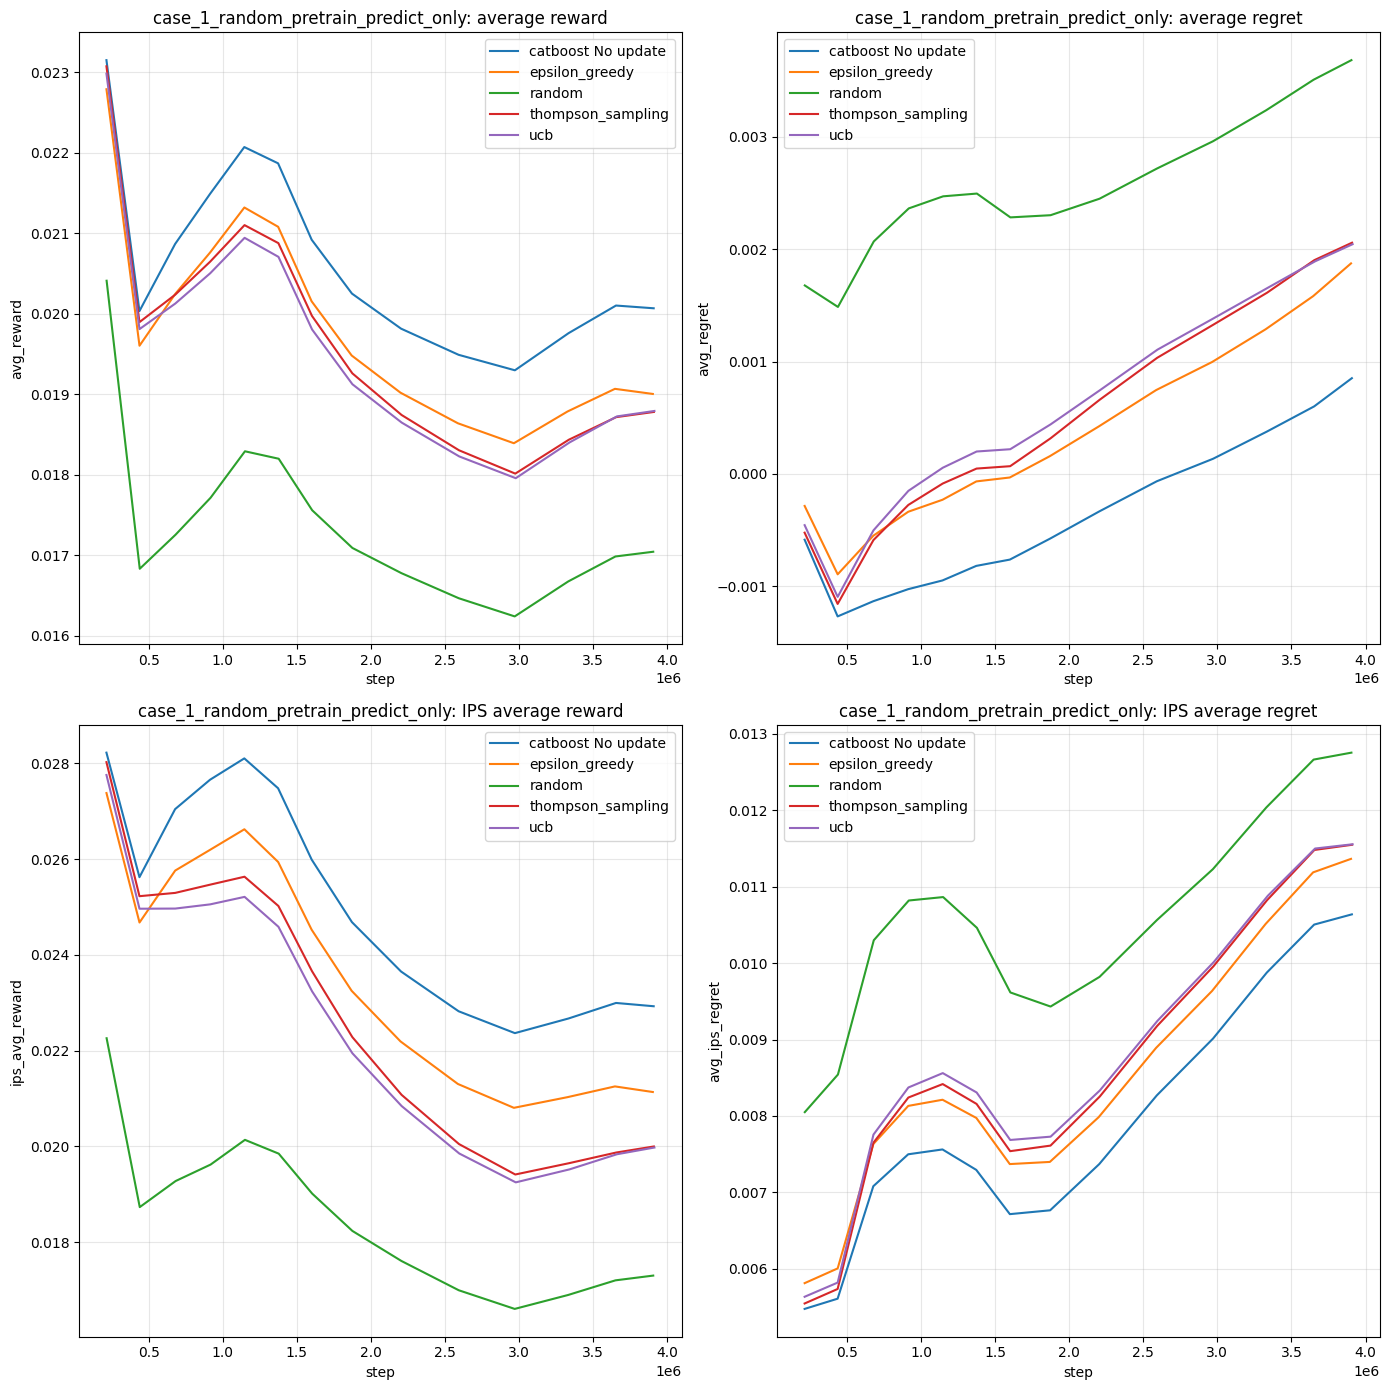

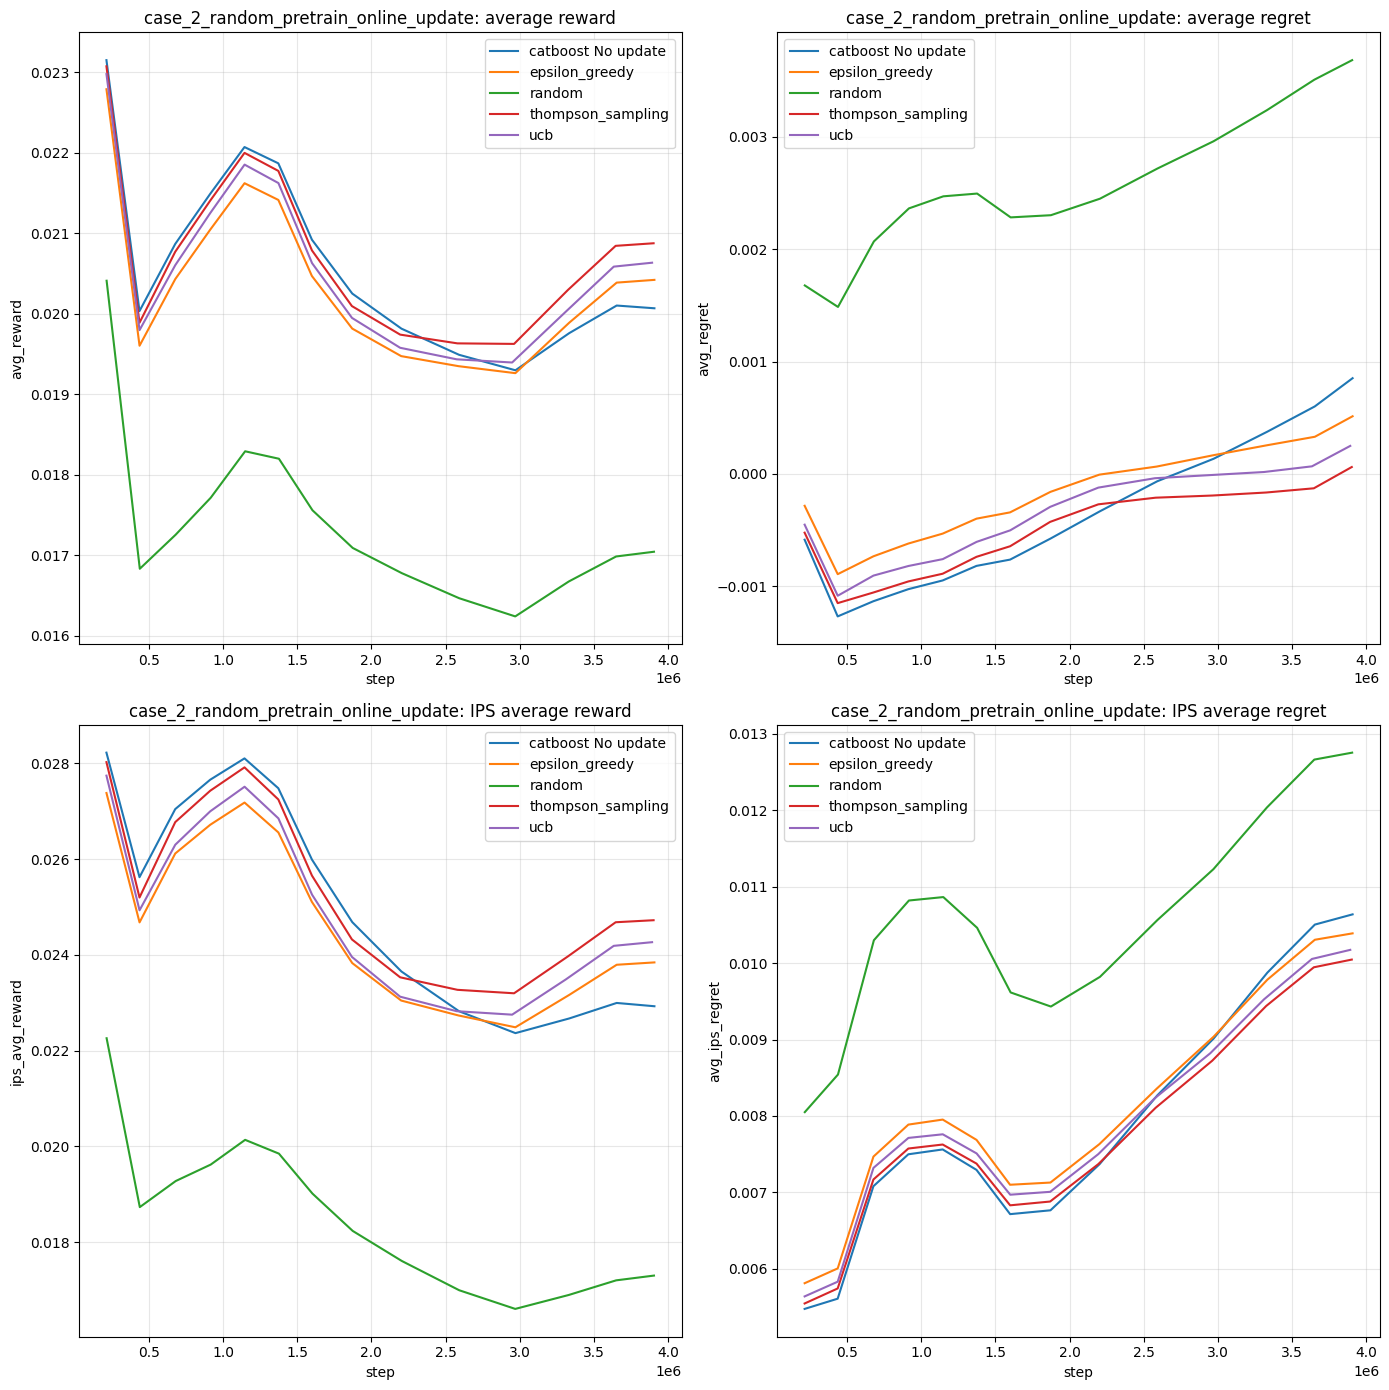

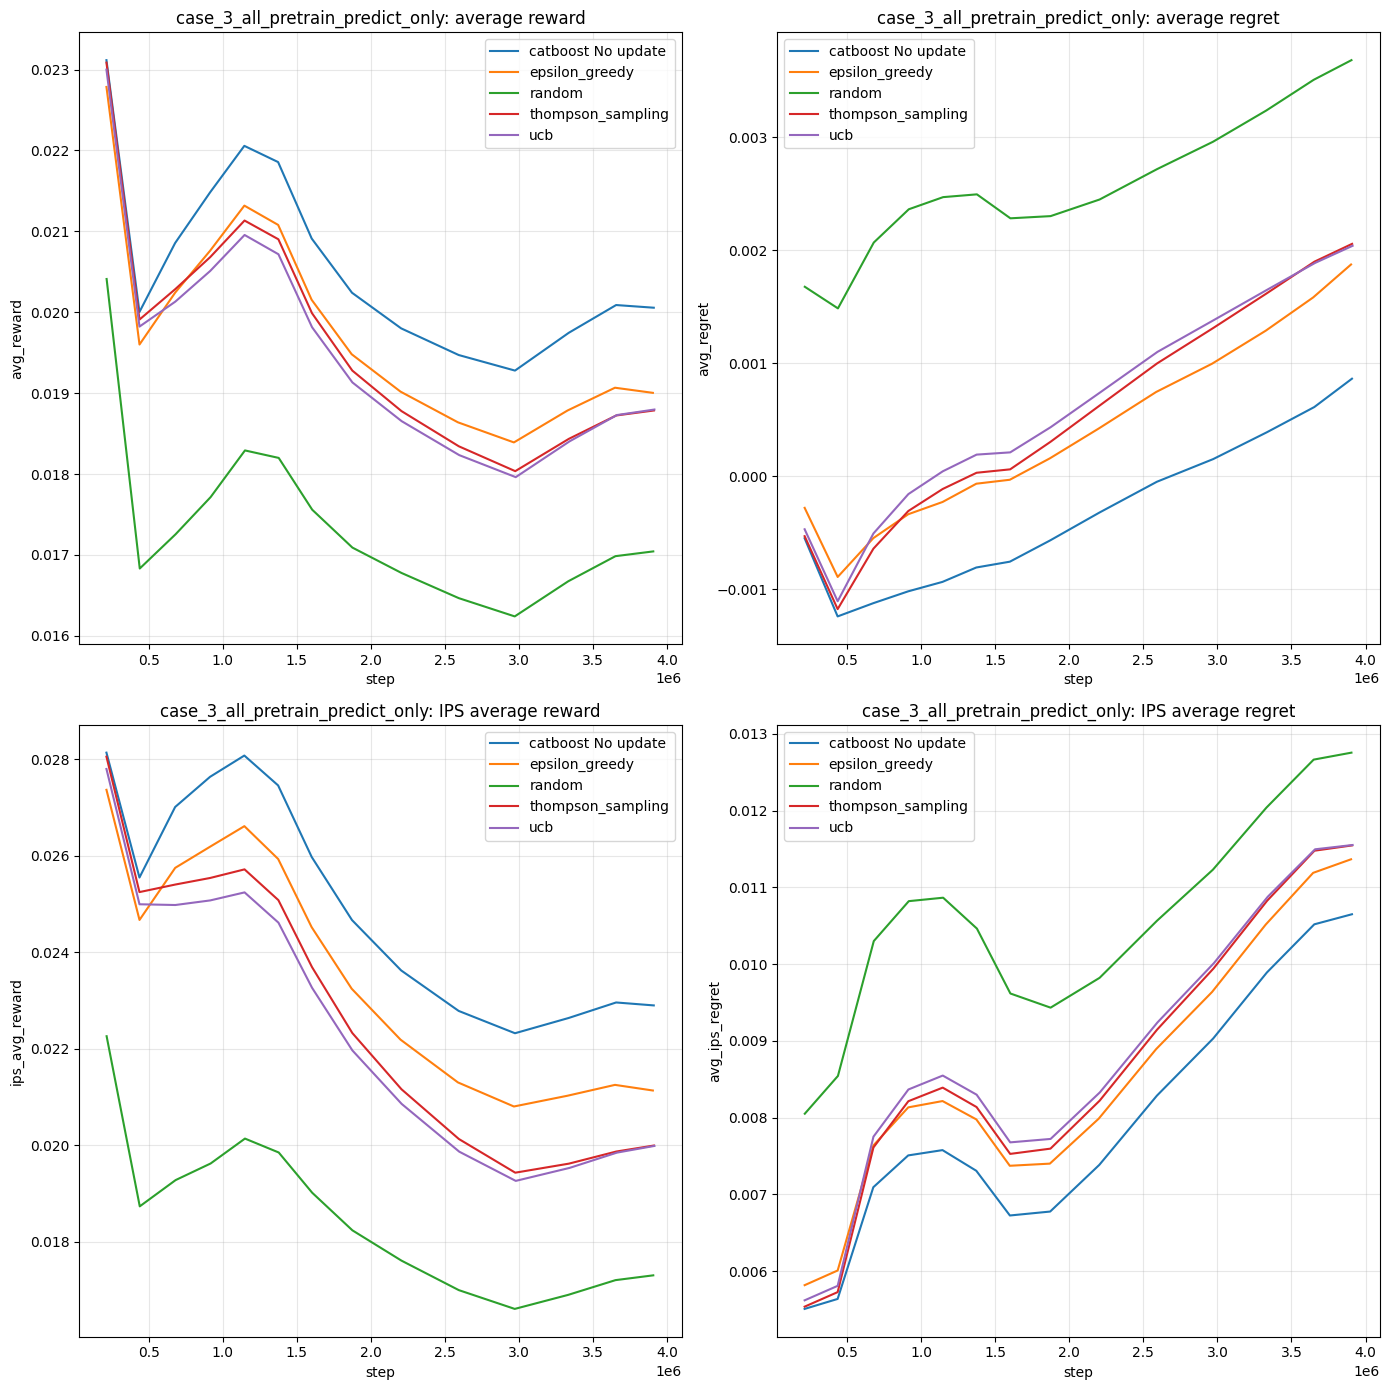

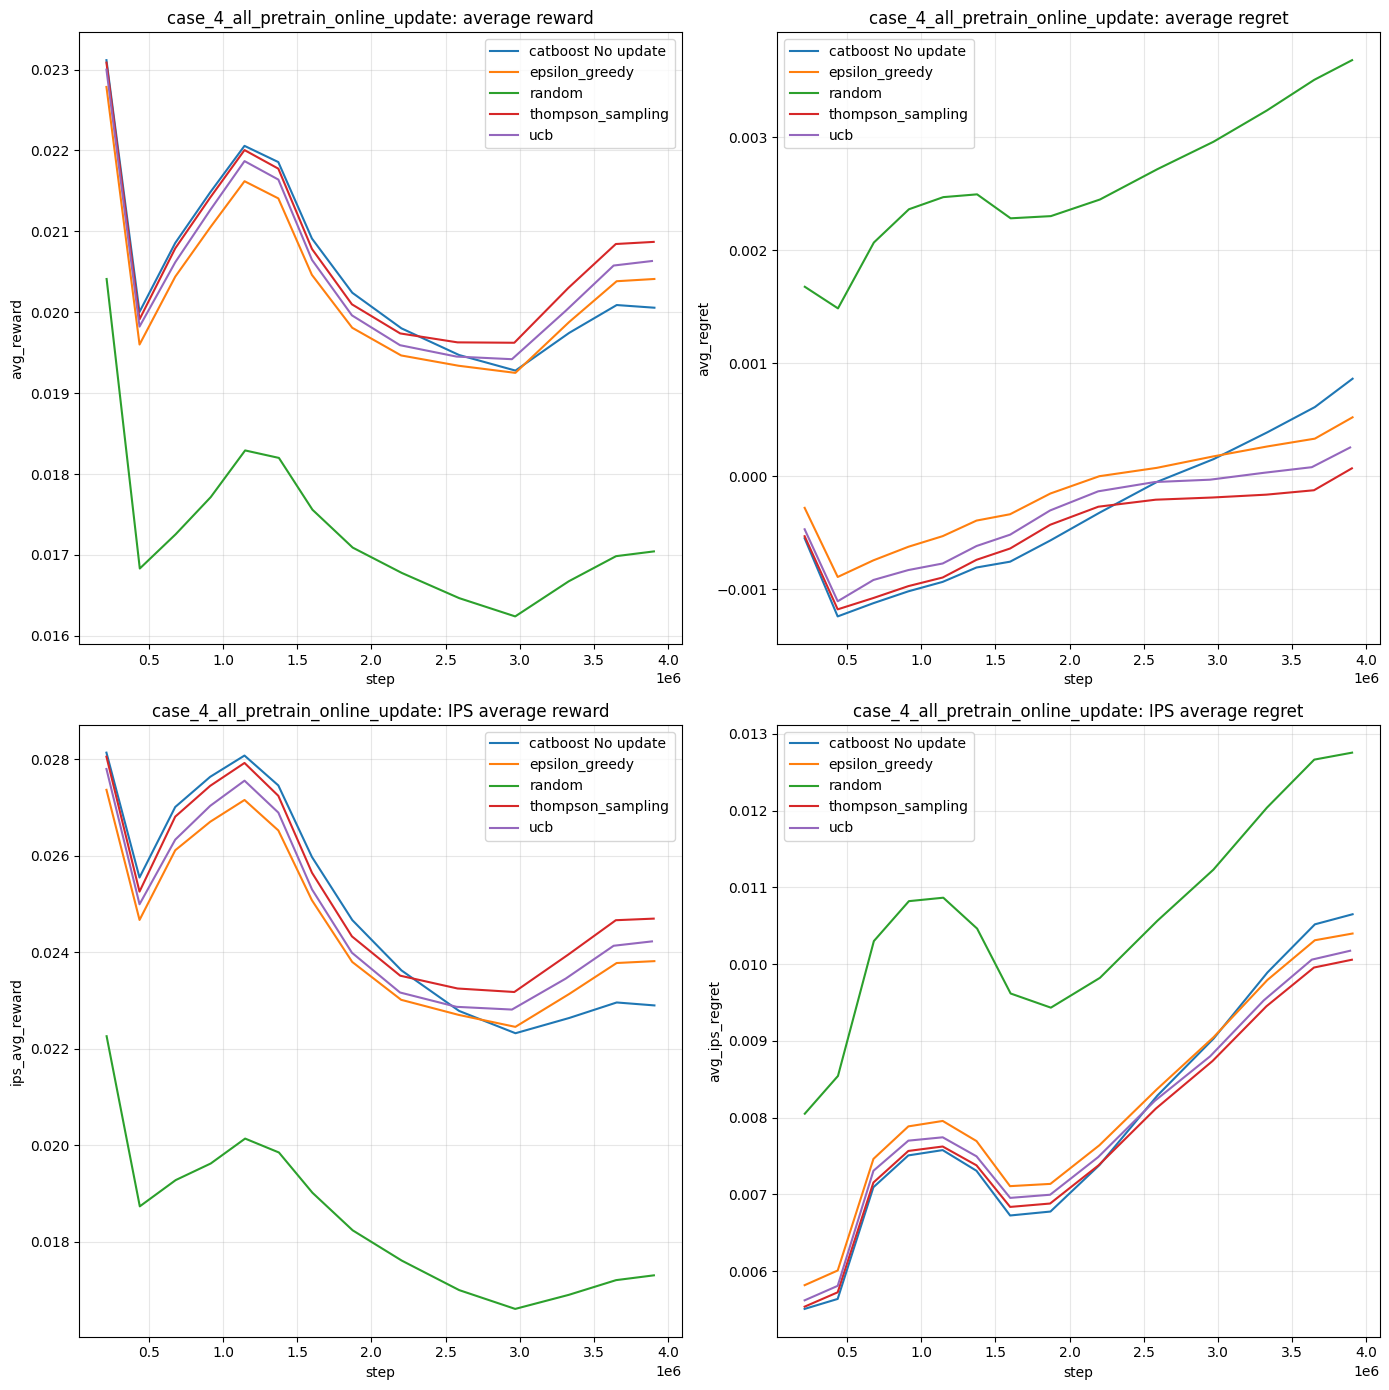

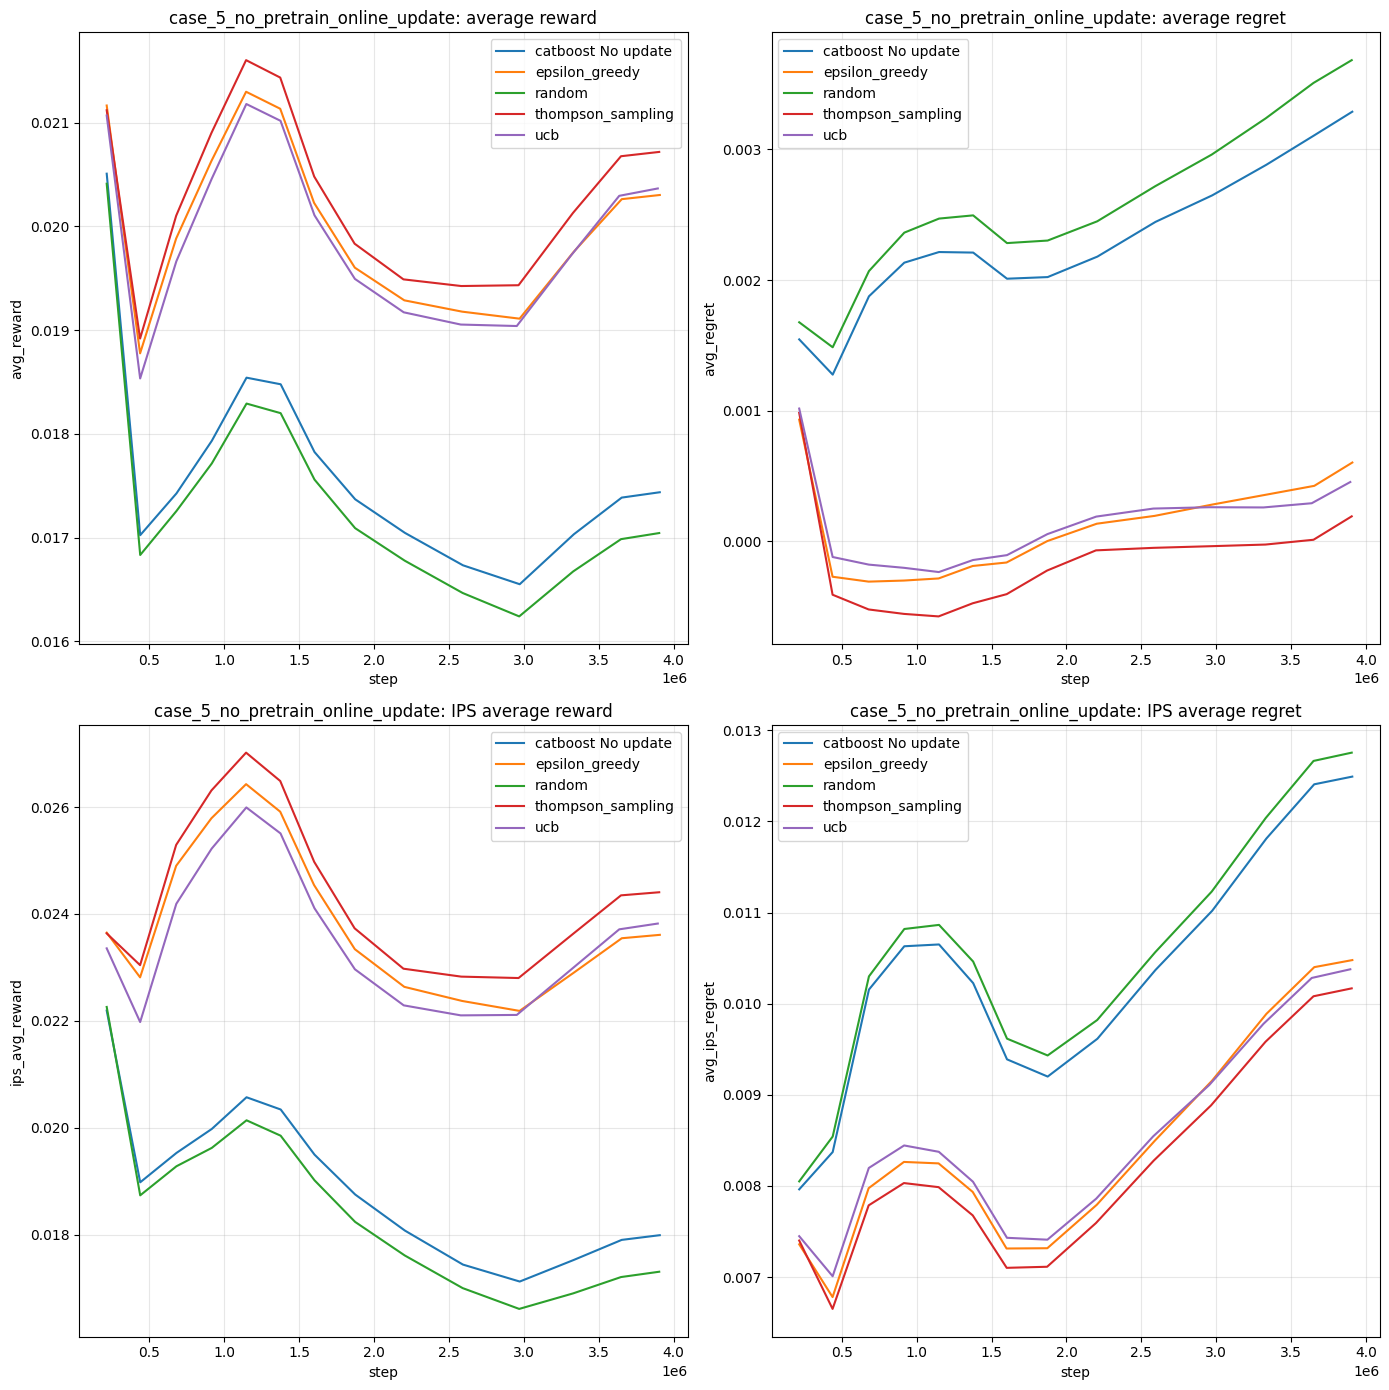

In [9]:
if not history_df.empty:
    for scenario_name, part in history_df.groupby('scenario'):
        fig, axes = plt.subplots(2, 2, figsize=(14, 14))

        for algo, algo_df in part.groupby('algo'):
            max_step = int(algo_df['step'].max()) if len(algo_df) else 0
            stride = max(1, int(round(max_step * 0.05)))  # каждые 5%
            ds = algo_df.iloc[stride::stride] if len(algo_df) > stride else algo_df  # стартуем с 5%

            axes[0, 0].plot(ds['step'], ds['avg_reward'], label=algo)
            axes[0, 1].plot(ds['step'], ds['avg_regret'], label=algo)
            axes[1, 0].plot(ds['step'], ds['ips_avg_reward'], label=algo)
            axes[1, 1].plot(ds['step'], ds['avg_ips_regret'], label=algo)

        axes[0, 0].set_title(f'{scenario_name}: average reward')
        axes[0, 0].set_xlabel('step')
        axes[0, 0].set_ylabel('avg_reward')

        axes[0, 1].set_title(f'{scenario_name}: average regret')
        axes[0, 1].set_xlabel('step')
        axes[0, 1].set_ylabel('avg_regret')
        # axes[0, 1].set_yscale('log')

        axes[1, 0].set_title(f'{scenario_name}: IPS average reward')
        axes[1, 0].set_xlabel('step')
        axes[1, 0].set_ylabel('ips_avg_reward')

        axes[1, 1].set_title(f'{scenario_name}: IPS average regret')
        axes[1, 1].set_xlabel('step')
        axes[1, 1].set_ylabel('avg_ips_regret')
        # axes[1, 1].set_yscale('log')

        for ax in axes.ravel():
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('History is empty.')

## 6) Графики по статистикам action'ов
Показывает динамику общего числа уникальных action'ов и количества новых action'ов по дням/checkpoint'ам.

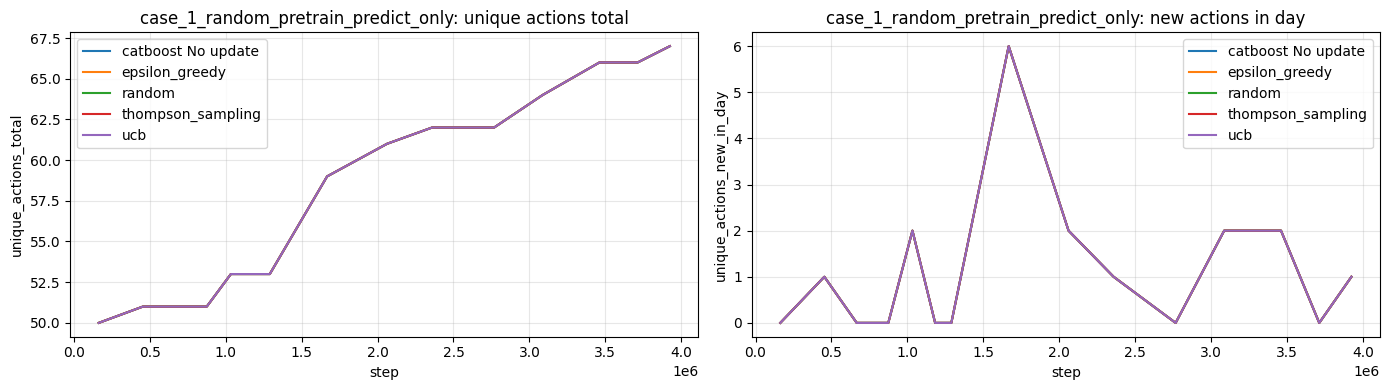

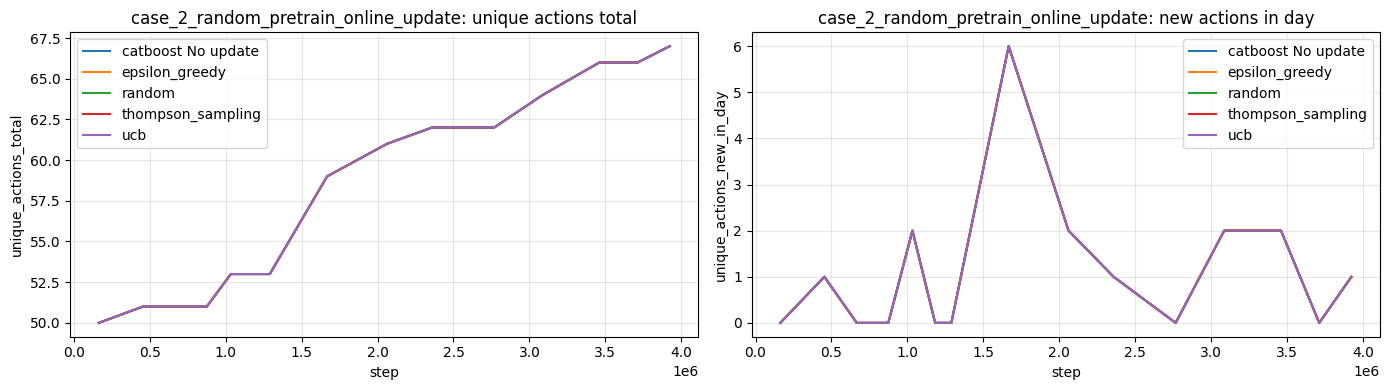

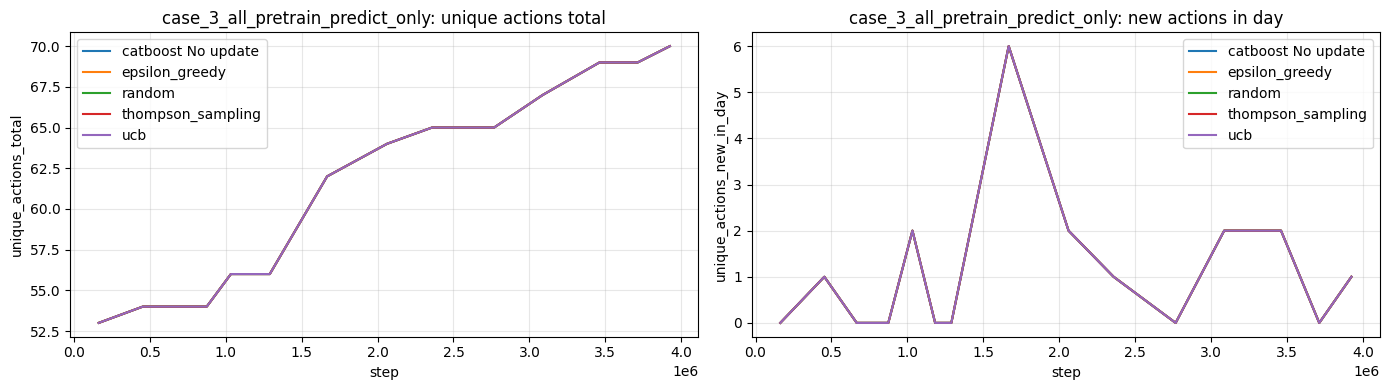

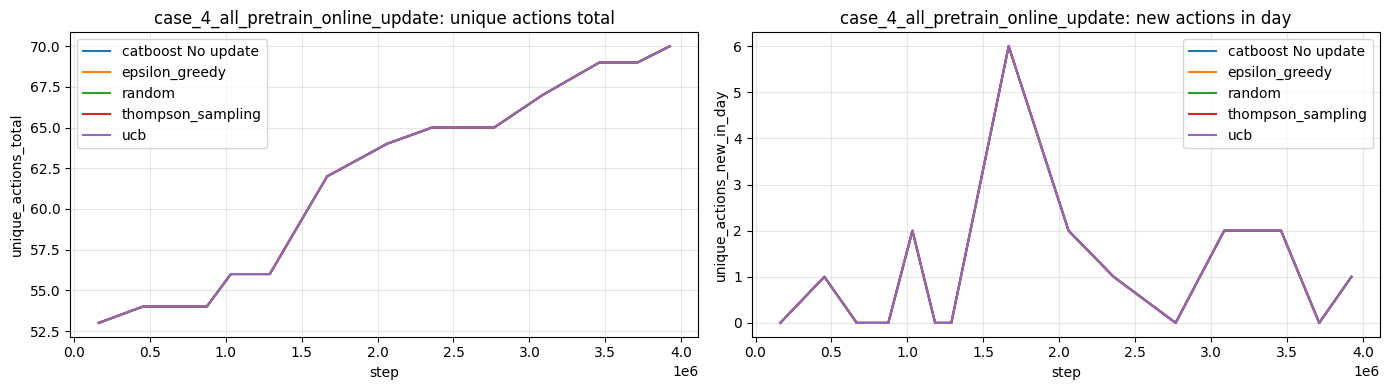

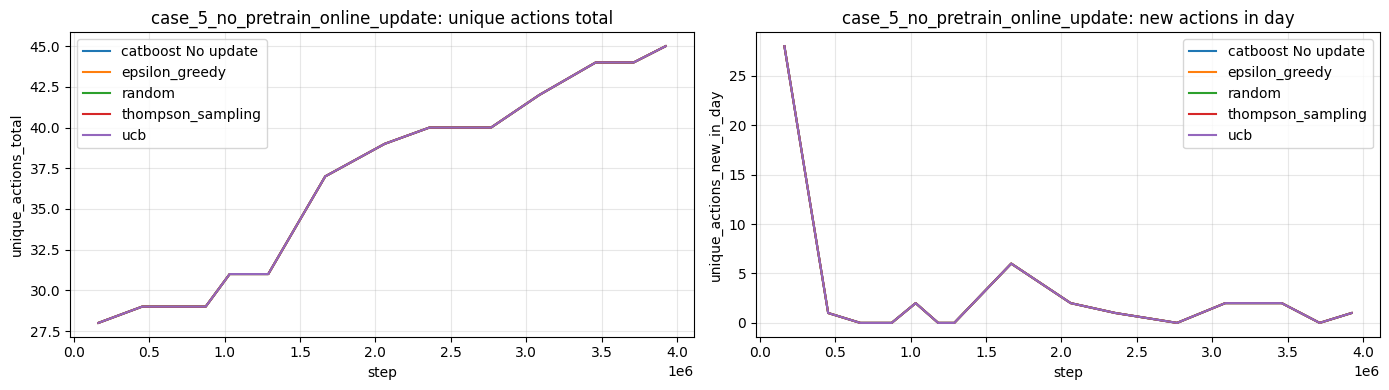

In [7]:
if not action_stats_df.empty:
    for scenario_name, part in action_stats_df.groupby('scenario'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for algo, algo_df in part.groupby('algo'):
            algo_df = algo_df.sort_values('step')
            axes[0].plot(algo_df['step'], algo_df['unique_actions_total'], label=algo)
            axes[1].plot(algo_df['step'], algo_df['unique_actions_new_in_day'], label=algo)

        axes[0].set_title(f"{scenario_name}: unique actions total")
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('unique_actions_total')

        axes[1].set_title(f"{scenario_name}: new actions in day")
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('unique_actions_new_in_day')

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('action_stats_df is empty.')


## 7) Сохранение артефактов

In [8]:
OUT_DIR = ROOT / 'artifacts'
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUT_DIR / 'metrics.csv'
history_path = OUT_DIR / 'history.csv'
action_stats_path = OUT_DIR / 'action_stats.csv'

metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)
action_stats_df.to_csv(action_stats_path, index=False)

print('saved metrics:', metrics_path)
print('saved history:', history_path)
print('saved action stats:', action_stats_path)


saved metrics: /Users/ogrobertino/BanditsResearch/artifacts/metrics.csv
saved history: /Users/ogrobertino/BanditsResearch/artifacts/history.csv
saved action stats: /Users/ogrobertino/BanditsResearch/artifacts/action_stats.csv
